# 건강검진정보 분석

### 1\. 데이터 불러오기

In [ ]:
import platform
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


os_name = platform.system()

if os_name == 'Windows': 
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif os_name == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'], rc={"axes.unicode_minus": False})

In [2]:
health_df = pd.read_csv('../data/건강검진정보_2024_20260325.csv', encoding='cp949')
health_df.head(3)


,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,1.0,1.0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,1.0,1.0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,1.0,1.0


### 2\. Data Shape 확인


In [ ]:
health_df.shape

(1000000, 17)

17개의 컬럼과 1000000개의 데이터가 있다

### 3\. Data Type 확인


In [ ]:
health_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   기준년도     1000000 non-null  int64  
 1   가입자일련번호  1000000 non-null  int64  
 2   시도코드     1000000 non-null  int64  
 3   성별코드     1000000 non-null  int64  
 4   연령대코드    1000000 non-null  int64  
 5   신장       1000000 non-null  int64  
 6   체중       1000000 non-null  int64  
 7   허리둘레     999505 non-null   float64
 8   시력_좌     999807 non-null   float64
 9   시력_우     999808 non-null   float64
 10  청력_좌     999852 non-null   float64
 11  청력_우     999852 non-null   float64
 12  수축기혈압    994210 non-null   float64
 13  이완기혈압    994211 non-null   float64
 14  식전혈당     994153 non-null   float64
 15  흡연상태     999882 non-null   float64
 16  음주여부     999955 non-null   float64
dtypes: float64(10), int64(7)
memory usage: 129.7 MB


In [5]:
numeric_cols = [
    '신장','체중','허리둘레',
    '시력_좌','시력_우',
    '수축기혈압','이완기혈압','식전혈당'
]

categorical_cols = [
    '기준년도','가입자일련번호',
    '시도코드','성별코드','연령대코드',
    '청력_좌','청력_우','흡연상태','음주여부'
]

범주형임에도 숫자로 입력되어 잘 구분되지 않으므로 직접 구분 해줌

### 4\. 결측값 확인 및 처리

In [ ]:
health_df[numeric_cols].isna().sum()

신장          0
체중          0
허리둘레      495
시력_좌      193
시력_우      192
수축기혈압    5790
이완기혈압    5789
식전혈당     5847
dtype: int64

수치형 변수 중 결측값이 있는 변수는

"허리둘레", "시력_좌", "시력_우", "수축기혈입", "이완기혈압", "식전혈당"

In [7]:
health_df[categorical_cols].isna().sum()

기준년도         0
가입자일련번호      0
시도코드         0
성별코드         0
연령대코드        0
청력_좌       148
청력_우       148
흡연상태       118
음주여부        45
dtype: int64

범주형 변수 중 결측값이 있는 변수는

"청력_좌", "청력_우", "흡연상태", "음주여부"

In [ ]:
health_df.isna().mean()*100


기준년도       0.0000
가입자일련번호    0.0000
시도코드       0.0000
성별코드       0.0000
연령대코드      0.0000
신장         0.0000
체중         0.0000
허리둘레       0.0495
시력_좌       0.0193
시력_우       0.0192
청력_좌       0.0148
청력_우       0.0148
수축기혈압      0.5790
이완기혈압      0.5789
식전혈당       0.5847
흡연상태       0.0118
음주여부       0.0045
dtype: float64

컬럼 정보에서 시력에서 9.9는 실명했다는 거를 뜻함

 9.9가 있으면 분포가 왜곡되기 때문에 실명여부 컬럼을 새롭게 만들어주고

 기존의 9.9는 지우고 nan으로 대체

 그리고 "시력_좌", "시력_우"에 3 이라는 잘못된 데이터가 있기 떄문에 3을 지우고 nan으로 대체

In [9]:
# 컬럼별 결측값을 적절하게 처리하는 코드를 입력하세요
health_df['시력_좌_실명여부']  = np.where(health_df['시력_좌'] == 9.9, 1, 0) # 함수를 사용하여 시력_좌 컬럼이 9.9인 경우 1, 아닌 경우 0으로 새로운 컬럼 생성
health_df['시력_좌'] = health_df['시력_좌'].replace(9.9, np.nan)

health_df['시력_우_실명여부']  = np.where(health_df['시력_우'] == 9.9, 1, 0) # 함수를 사용하여 시력_우 컬럼이 9.9인 경우 1, 아닌 경우 0으로 새로운 컬럼 생성
health_df['시력_우'] = health_df['시력_우'].replace(9.9, np.nan)

health_df['청력_좌'] = health_df['청력_좌'].replace([3, '3'], np.nan)
health_df['청력_우'] = health_df['청력_우'].replace([3, '3'], np.nan)

In [10]:
health_df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,시력_좌_실명여부,시력_우_실명여부
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,1.0,1.0,0,0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,1.0,1.0,0,0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,1.0,1.0,0,0
3,2024,3770599,41,1,16,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,1.0,1.0,0,0
4,2024,2634185,41,1,11,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,1.0,1.0,0,0


In [11]:
health_df.describe()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,시력_좌_실명여부,시력_우_실명여부
count,1000000.0,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,999505.000000,997021.000000,997098.000000,997462.000000,997526.000000,994210.000000,994211.000000,994153.000000,999882.000000,999955.000000,1000000.000000,1000000.000000
mean,2024.0,2.499783e+06,33.924477,1.482070,10.671586,162.732935,64.563640,81.564217,0.928089,0.926488,1.032481,1.031283,122.695203,75.224772,100.977201,1.536699,0.656951,0.002786,0.002710
std,0.0,1.443848e+06,12.509850,0.499679,3.066531,9.355593,14.020046,10.941088,0.328300,0.327553,0.177275,0.174083,14.595222,10.361867,22.995949,0.780901,0.474728,0.052709,0.051987
min,2024.0,9.000000e+00,11.000000,1.000000,5.000000,130.000000,30.000000,6.800000,0.100000,0.100000,1.000000,1.000000,60.000000,11.000000,17.000000,1.000000,0.000000,0.000000,0.000000
25%,2024.0,1.247716e+06,27.000000,1.000000,8.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,1.000000,0.000000,0.000000,0.000000
50%,2024.0,2.499856e+06,41.000000,1.000000,11.000000,165.000000,65.000000,81.200000,0.900000,0.900000,1.000000,1.000000,121.000000,75.000000,96.000000,1.000000,1.000000,0.000000,0.000000
75%,2024.0,3.749790e+06,43.000000,2.000000,13.000000,170.000000,75.000000,88.500000,1.200000,1.200000,1.000000,1.000000,132.000000,81.000000,106.000000,2.000000,1.000000,0.000000,0.000000
max,2024.0,5.000000e+06,49.000000,2.000000,18.000000,195.000000,135.000000,999.000000,2.000000,2.500000,2.000000,2.000000,271.000000,182.000000,991.000000,3.000000,1.000000,1.000000,1.000000


결측치가 있는 모든 수치형 컬럼을 중앙값으로 대체

In [12]:
num_missing_cols = ['허리둘레', '수축기혈압', '이완기혈압', '식전혈당', '시력_좌', '시력_우']

for col in num_missing_cols:
    if health_df[col].isna().sum() > 0: # 위의 컬럼들의 결측치 갯수가 0 이상이면
        health_df[col] = health_df[col].fillna(health_df[col].median()) # 결측치를 중앙값으로 대체



결측치가 있는 모든 범주형 데이터는 최빈값으로 대체

In [13]:
cat_missing_cols = ['청력_좌', '청력_우', '흡연상태', '음주여부']

for col in cat_missing_cols:
    if health_df[col].isna().sum():
        health_df[col] = health_df[col].fillna(health_df[col].mode()[0])

health_df[cat_missing_cols] = health_df[cat_missing_cols].astype('int64')


In [14]:
health_df.isna().sum()

기준년도         0
가입자일련번호      0
시도코드         0
성별코드         0
연령대코드        0
신장           0
체중           0
허리둘레         0
시력_좌         0
시력_우         0
청력_좌         0
청력_우         0
수축기혈압        0
이완기혈압        0
식전혈당         0
흡연상태         0
음주여부         0
시력_좌_실명여부    0
시력_우_실명여부    0
dtype: int64

### 5\. 중복값 확인 및 처리

In [ ]:
health_df.duplicated().sum()

np.int64(0)

중복값을 허용하지 않는 "가입자일련번호"도 다시 한번 확인

In [16]:
health_df['가입자일련번호'].duplicated().sum()

np.int64(0)

### 6\. 이상치 확인 및 처리

In [ ]:
health_df[numeric_cols].describe()

,신장,체중,허리둘레,시력_좌,시력_우,수축기혈압,이완기혈압,식전혈당
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,162.732935,64.563640,81.564036,0.928006,0.926411,122.685388,75.223471,100.948099
std,9.355593,14.020046,10.938382,0.327814,0.327081,14.553476,10.331845,22.931762
min,130.000000,30.000000,6.800000,0.100000,0.100000,60.000000,11.000000,17.000000
25%,155.000000,55.000000,74.000000,0.700000,0.700000,112.000000,68.000000,89.000000
50%,165.000000,65.000000,81.200000,0.900000,0.900000,121.000000,75.000000,96.000000
75%,170.000000,75.000000,88.500000,1.200000,1.200000,132.000000,81.000000,106.000000
max,195.000000,135.000000,999.000000,2.000000,2.500000,271.000000,182.000000,991.000000


수치형 변수에 대한 통계량을 확인했을 때

평균과 중앙값, 최대,최소를 확인했을 때 이상치 유력 후보는

"허리둘레", "시력_좌", "시력_우",  "수축기 혈압", "이완기 혈압", "식전혈당"

히스토그램을 통해서 이상치를 확인

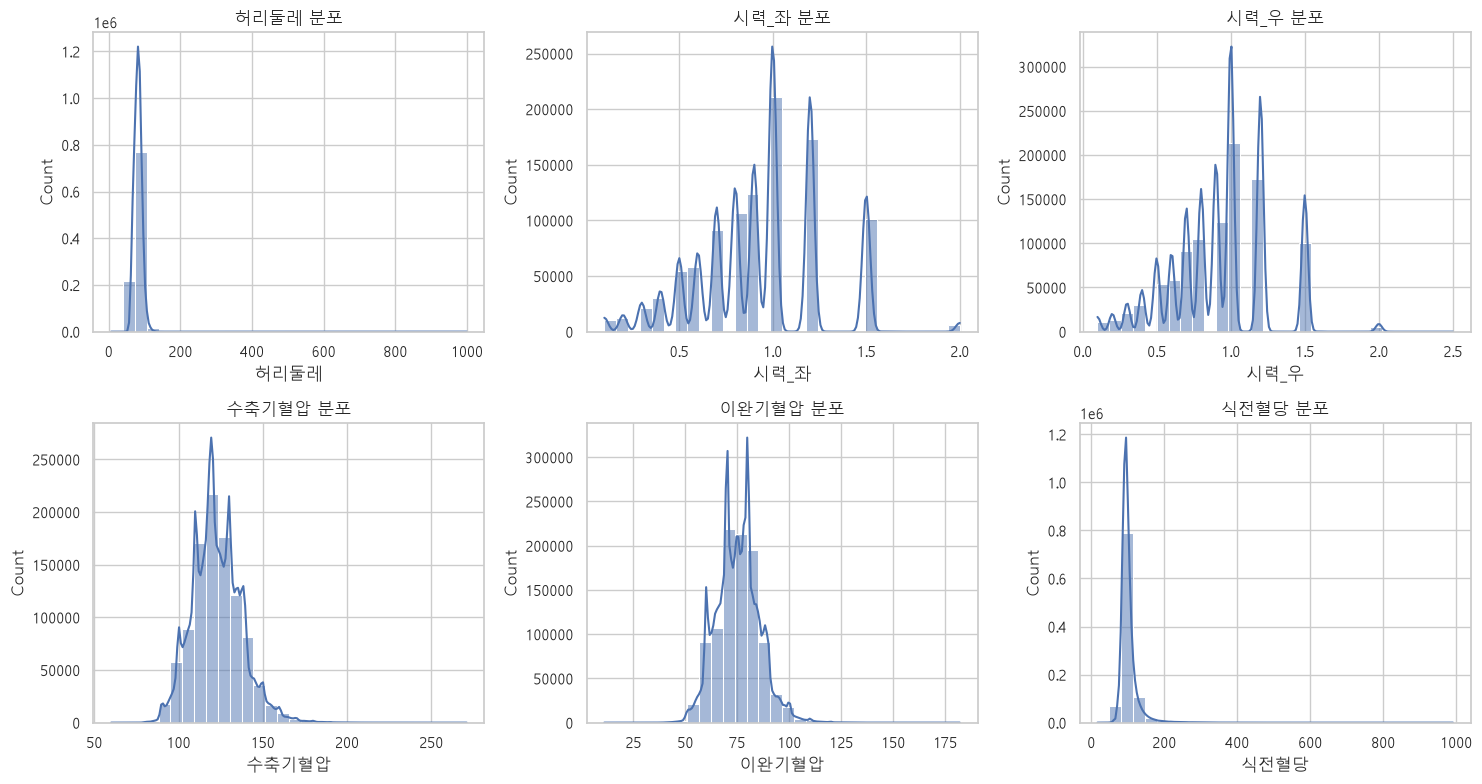

In [ ]:
fig, axes = plt.subplots(2, 3, figsize = (15,8))

sns.histplot(data = health_df, x = "허리둘레", kde = True, bins = 30, ax = axes[0,0])
axes[0,0].set_title("허리둘레 분포")

sns.histplot(data = health_df, x = "시력_좌", kde = True, bins = 30, ax = axes[0,1])
axes[0,1].set_title("시력_좌 분포")

sns.histplot(data = health_df, x = "시력_우", kde = True, bins = 30, ax = axes[0,2])
axes[0,2].set_title("시력_우 분포")

sns.histplot(data = health_df, x = "수축기혈압", kde = True, bins = 30, ax = axes[1,0])
axes[1,0].set_title("수축기혈압 분포")

sns.histplot(data = health_df, x = "이완기혈압", kde = True, bins = 30, ax = axes[1,1])
axes[1,1].set_title("이완기혈압 분포")

sns.histplot(data = health_df, x = "식전혈당", kde = True, bins = 30, ax = axes[1,2])
axes[1,2].set_title("식전혈당 분포")

fig.tight_layout()
plt.show()

그래프 확인결과

"허리둘레", "수축기혈압", "이완기혈압", "식전혈당"이 이상치 제거가 필요하다고 판단


In [19]:
q1_waist = health_df['허리둘레'].quantile(0.25)
q3_waist = health_df['허리둘레'].quantile(0.75)
iqr_waist = q3_waist-q1_waist

waist_upper = q3_waist + 1.5 * iqr_waist
waist_lower = q1_waist - 1.5 * iqr_waist

health_df = health_df[(health_df["허리둘레"] >= waist_lower) & (health_df["허리둘레"] <= waist_upper)]

In [20]:
q1_bp = health_df['수축기혈압'].quantile(0.25)
q3_bp = health_df['수축기혈압'].quantile(0.75)
iqr_bp = q3_bp-q1_bp

bp_upper = q3_bp + 1.5 * iqr_bp
bp_lower = q1_bp - 1.5 * iqr_bp

health_df = health_df[(health_df["수축기혈압"] >= bp_lower) & (health_df["수축기혈압"] <= bp_upper)]

In [21]:
q1_bp = health_df['이완기혈압'].quantile(0.25)
q3_bp = health_df['이완기혈압'].quantile(0.75)
iqr_bp = q3_bp-q1_bp

bp_upper = q3_bp + 1.5 * iqr_bp
bp_lower = q1_bp - 1.5 * iqr_bp

health_df = health_df[(health_df["이완기혈압"] >= bp_lower) & (health_df["이완기혈압"] <= bp_upper)]

In [22]:
q1_glucose = health_df['식전혈당'].quantile(0.25)
q3_glucose = health_df['식전혈당'].quantile(0.75)
iqr_glucose = q3_glucose-q1_glucose

glucose_upper = q3_glucose + 1.5 * iqr_glucose
glucose_lower = q1_glucose - 1.5 * iqr_glucose

health_df = health_df[(health_df["식전혈당"] >= glucose_lower) & (health_df["식전혈당"] <= glucose_upper)]

In [23]:
len(health_df)

908610

### 7\. 시도코드 & 연령대코드 정리
- `시도코드`: 11 → "서울특별시", 26 → "부산광역시", ... 이런 식으로 치환
- `연령대코드`: 1 → "0-4", 2 → "5-9", ... 이런 식으로 치환

In [ ]:
health_df['시도코드'] = health_df['시도코드'].replace({
    11 : "서울특별시", 26 : "부산광역시",
    27 : "대구광역시", 28 : "인천광역시",
    29 : "광주광역시", 30 : "대전광역시",
    31 : "울산광역시", 36 : "세종특별자치시",
    41 : "경기도", 42: "강원도",
    43 : "충청북도", 44 : '충청남도',
    45 : "전라북도", 46 : "전라남도",
    47 : "경상북도", 48 : "경상남도",
    49 : "제주특별자치도"
})
health_df['시도코드']

0           경기도
1           경기도
2           경기도
3           경기도
4           경기도
          ...  
999992    대구광역시
999994      경기도
999996    인천광역시
999997      경기도
999999      경기도
Name: 시도코드, Length: 908610, dtype: object

In [ ]:
health_df['연령대코드'] = health_df['연령대코드'].replace({
    1 : "0-4", 2 : "5-9", 3 : "10-14",
    4 : "15-19", 5 : "20-24", 6 : "25-29",
    7 : "30-34", 8 : "35-39", 9 : "40-44",
    10 : "45-49", 11 : "50-54", 12 : "55-59",
    13 : "60-64", 14 : "65-69", 15 : "70-74", 
    16 : "75-79", 17 : "80-84", 18 : "85세 이상"
})
health_df['연령대코드']

0         60-64
1         50-54
2         60-64
3         75-79
4         50-54
          ...  
999992    60-64
999994    60-64
999996    55-59
999997    55-59
999999    45-49
Name: 연령대코드, Length: 908610, dtype: object

'성별코드', '흡연상태', '음주여부', '청력_좌', '청력_우'도 가독성을 위해 변경

In [26]:
health_df['성별코드'] = health_df['성별코드'].replace({1: "남성", 2: "여성"})

health_df['흡연상태'] = health_df['흡연상태'].replace({1: "비흡연", 2: "과거흡연", 3: "현재흡연"})

health_df['음주여부'] = health_df['음주여부'].replace({0: "비음주", 1: "음주"})

health_df['청력_좌'] = health_df['청력_좌'].replace({1: "정상", 2: "비정상"})

health_df['청력_우'] = health_df['청력_우'].replace({1: "정상", 2: "비정상"})

In [27]:
health_df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,시력_좌_실명여부,시력_우_실명여부
0,2024,4831755,경기도,여성,60-64,160,50,70.0,1.0,1.0,정상,정상,107.0,77.0,70.0,비흡연,음주,0,0
1,2024,1154608,경기도,여성,50-54,155,60,74.9,1.0,1.0,정상,정상,104.0,69.0,81.0,비흡연,음주,0,0
2,2024,3318236,경기도,여성,60-64,150,55,74.0,1.0,1.0,정상,정상,134.0,83.0,106.0,비흡연,음주,0,0
3,2024,3770599,경기도,남성,75-79,160,70,89.0,1.0,1.0,정상,정상,119.0,73.0,97.0,비흡연,음주,0,0
4,2024,2634185,경기도,남성,50-54,175,65,76.0,1.0,1.0,정상,정상,103.0,64.0,115.0,비흡연,음주,0,0


### 8\. 수치형 변수와 범주형 변수의 기술통계량 확인

In [ ]:
health_df[numeric_cols].describe()

,신장,체중,허리둘레,시력_좌,시력_우,수축기혈압,이완기혈압,식전혈당
count,908610.000000,908610.000000,908610.000000,908610.000000,908610.000000,908610.000000,908610.000000,908610.000000
mean,162.678806,63.877786,80.798180,0.935023,0.933249,121.591198,74.612465,96.540281
std,9.317310,13.336406,10.254275,0.327881,0.327130,13.447404,9.576723,11.374454
min,130.000000,30.000000,52.300000,0.100000,0.100000,82.000000,49.000000,65.000000
25%,155.000000,55.000000,73.000000,0.700000,0.700000,112.000000,68.000000,89.000000
50%,165.000000,60.000000,81.000000,1.000000,1.000000,120.000000,75.000000,96.000000
75%,170.000000,70.000000,88.000000,1.200000,1.200000,130.000000,80.000000,103.000000
max,195.000000,135.000000,110.200000,2.000000,2.500000,162.000000,100.000000,129.000000


In [29]:
print(health_df["청력_좌"].unique())
print(health_df["청력_우"].unique())

['정상' '비정상']
['정상' '비정상']


In [ ]:
print(health_df["시도코드"].value_counts(normalize=True).head())
print(health_df["연령대코드"].value_counts(normalize=True).sort_index())
print(health_df["성별코드"].value_counts(normalize=True).sort_index())
print(health_df["흡연상태"].value_counts(normalize=True).sort_index())
print(health_df["음주여부"].value_counts(normalize=True).sort_index())
print(health_df["청력_좌"].value_counts(normalize=True).sort_index())
print(health_df["청력_우"].value_counts(normalize=True).sort_index())

시도코드
경기도      0.269238
서울특별시    0.174807
경상남도     0.064896
부산광역시    0.062886
인천광역시    0.059860
Name: proportion, dtype: float64
연령대코드
20-24     0.033356
25-29     0.072714
30-34     0.097466
35-39     0.076361
40-44     0.115689
45-49     0.092077
50-54     0.123373
55-59     0.098042
60-64     0.109724
65-69     0.071130
70-74     0.059109
75-79     0.025777
80-84     0.019150
85세 이상    0.006032
Name: proportion, dtype: float64
성별코드
남성    0.504653
여성    0.495347
Name: proportion, dtype: float64
흡연상태
과거흡연    0.171583
비흡연     0.654751
현재흡연    0.173666
Name: proportion, dtype: float64
음주여부
비음주    0.339676
음주     0.660324
Name: proportion, dtype: float64
청력_좌
비정상    0.030493
정상     0.969507
Name: proportion, dtype: float64
청력_우
비정상    0.029314
정상     0.970686
Name: proportion, dtype: float64


### 9\. 주요 수치형 변수의 분포 시각화

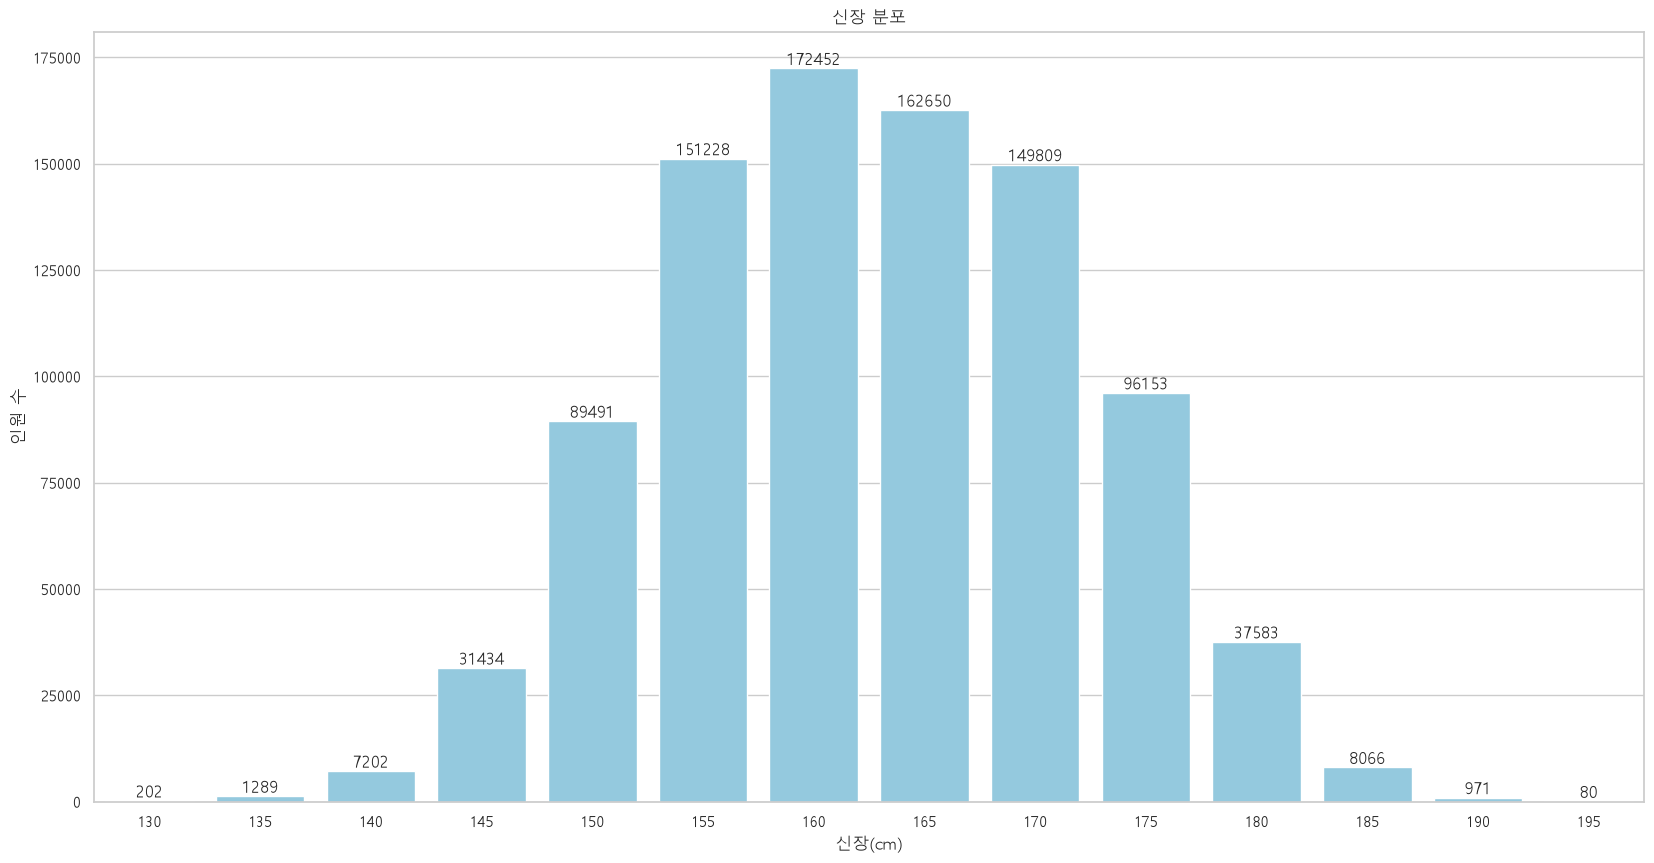

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.countplot(data = health_df, x = "신장", color = 'skyblue' )
plt.title("신장 분포")
plt.xlabel("신장(cm)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c,
                fmt='{:.0f}',
                label_type='edge');
plt.show()

그래프를 보면 정규분포의 형태로 되어있으며 155cm ~ 170cm 구간에 가장 많이 분포해 있고, 양끝으로 갈수록 빈도가 줄어든다

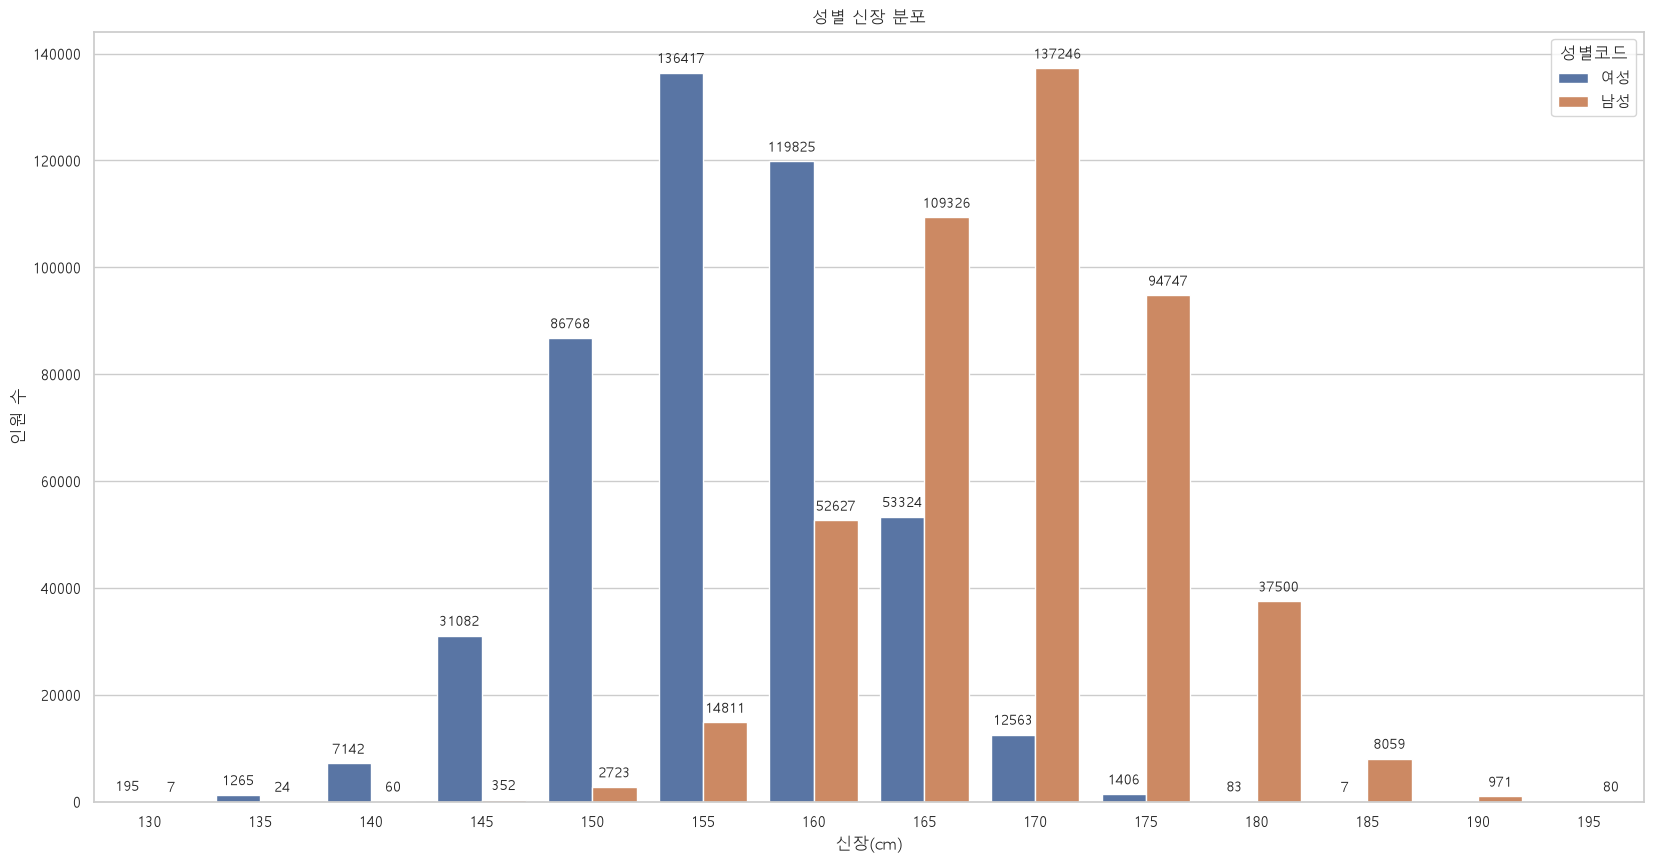

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.countplot(data = health_df, x = "신장",
                 hue = '성별코드')
plt.title("성별 신장 분포")
plt.xlabel("신장(cm)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c, fmt = '{:.0f}', label_type= 'edge', fontsize = 10, padding = 5)
plt.show()

여성은 150cm ~ 160cm 사이에 가장 많이 분포해 있고,
남성은 165cm ~ 175cm 사이에 가장 많이 분포해 있다.

또한 그래프를 보면 전체적으로 남성의 신장 분포가 오른쪽에 위치해 있어 여성보다 중앙값, 평균값이 더 높다고 해석할 수 있다.

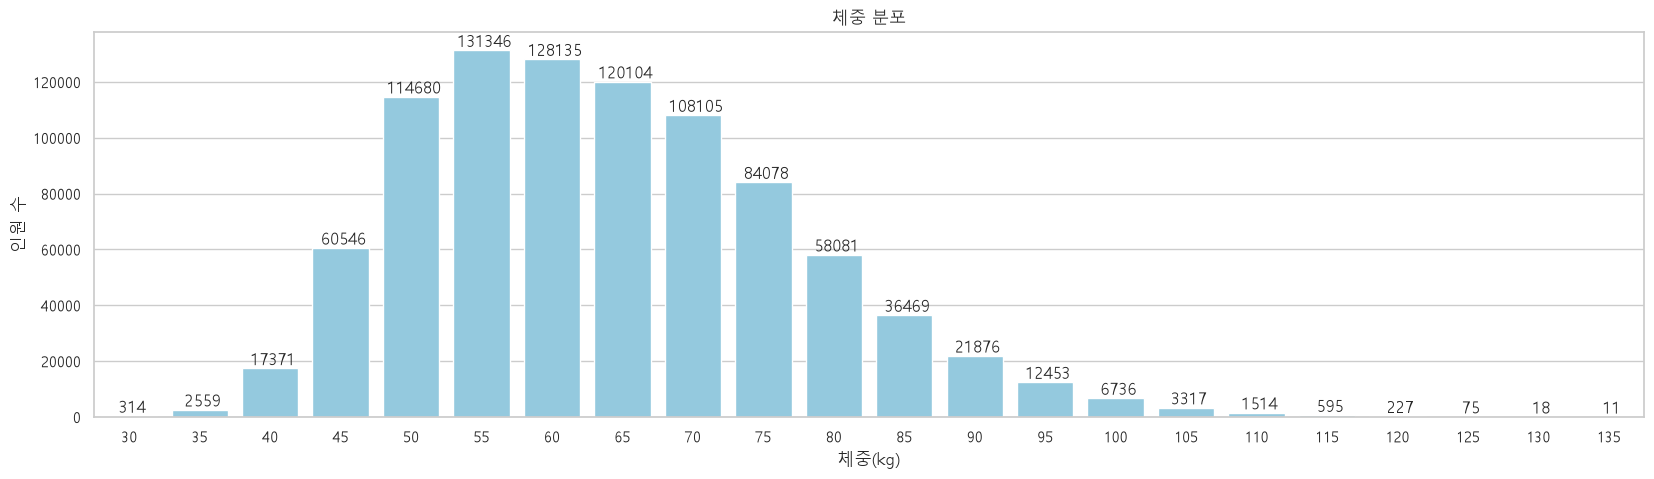

In [ ]:
plt.figure(figsize = (20,5))
ax = sns.countplot(data = health_df, x = "체중", color = 'skyblue')
plt.title("체중 분포")
plt.xlabel("체중(kg)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge')
plt.show()

오른쪽으로 긴 꼬리를 가진 형태이고 50kg ~ 70kg 구간에 가장 많이 분포해 있다.

또한 오른쪽 끝에 극단값이 존재하므로 중앙값이 평균값보다 더 높다고 해석할 수 있다.

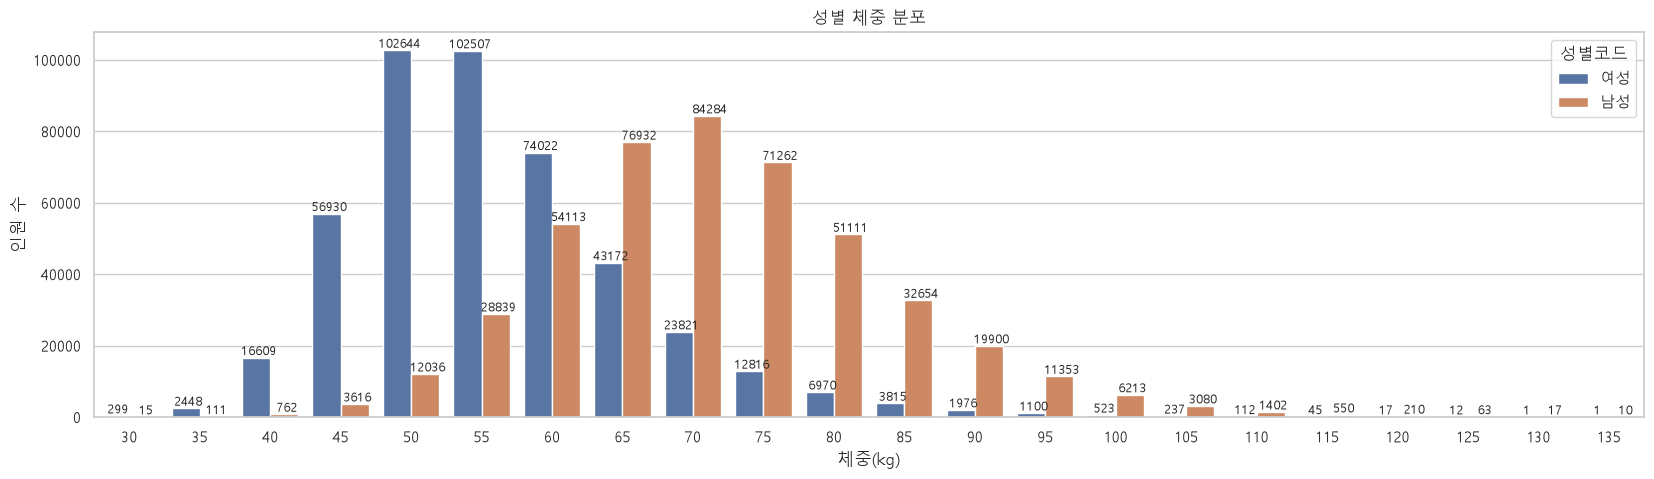

In [ ]:
plt.figure(figsize = (20,5))
ax = sns.countplot(data = health_df, x = "체중", hue = "성별코드")
plt.title("성별 체중 분포")
plt.xlabel("체중(kg)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 9)
plt.show()

여성은 50kg ~ 55kg 구간에 많이 분포해 있고,
남성은 65kg ~ 75kg 구간에 많이 분포해 있다

그래프를 보면 남성의 체중 분포가 전체적으로 오른쪽에 위치해 있어 여성보다 중앙값, 평균값이 더 높다고 해석할 수 있다.

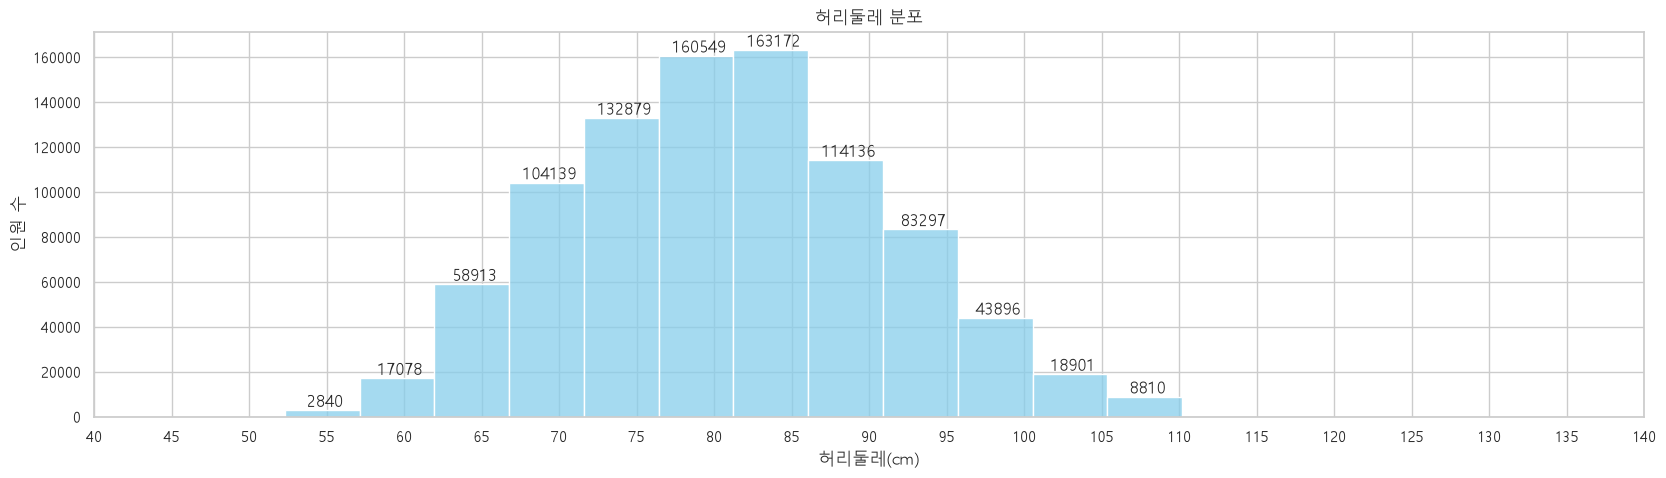

In [ ]:
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "허리둘레", color = 'skyblue', binwidth=5)
plt.title("허리둘레 분포")
plt.xlabel("허리둘레(cm)")
plt.ylabel("인원 수")
plt.xticks(np.arange(40,171,5))
plt.xlim(40, 140)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge')
plt.show()

위의 그래프는 정규분포의 형태로 되어있다. 허리둘레는 70cm ~ 90cm 구간에 가장 많이 분포해 있고 양끝으로 갈 수록 빈도가 줄어든다.

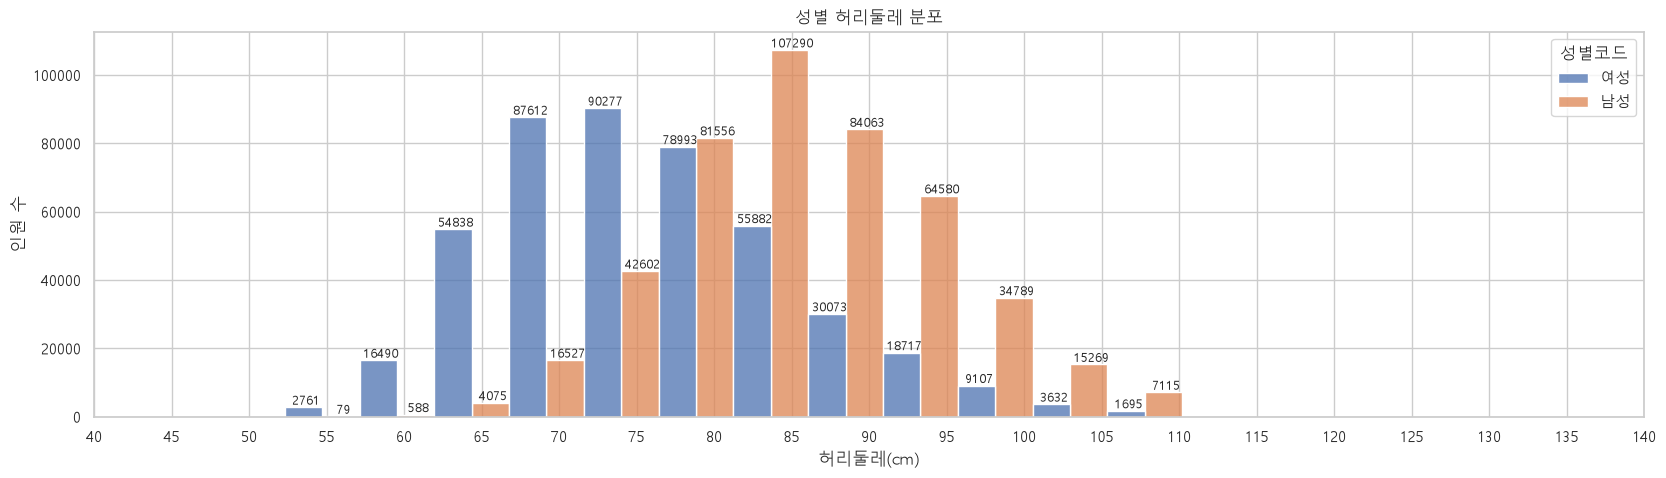

In [ ]:
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "허리둘레", color = 'gray', binwidth=5, hue = "성별코드", multiple='dodge')
plt.title("성별 허리둘레 분포")
plt.xlabel("허리둘레(cm)")
plt.ylabel("인원 수")
plt.xticks(np.arange(40,171,5))
plt.xlim(40, 140)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 9)
plt.show()

여성은 70cm ~ 80cm 사이에 많이 분포해 있고,
남성은 80cm ~ 90cm 사이에 많이 분포해 있다.

전체적인 그래프를 봤을 때 남성이 그래프가 여성보다 오른쪽에 있어 평균이나 중앙값이 더 높다고 해석할 수 있다.

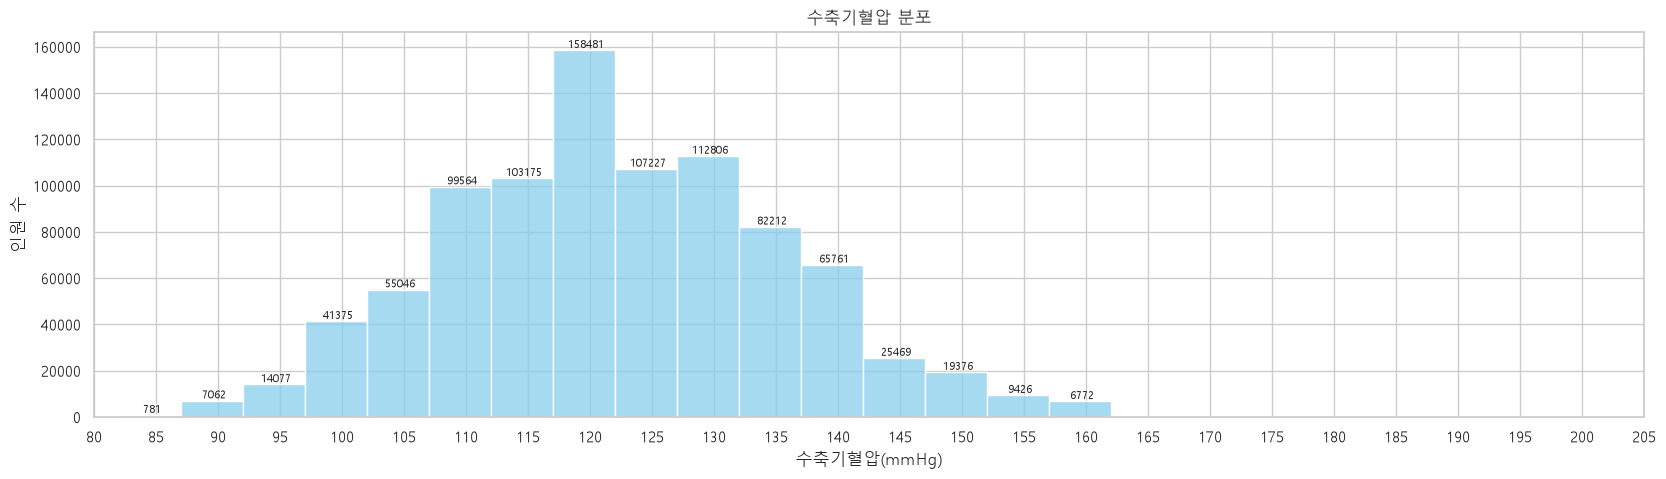

In [ ]:
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "수축기혈압", color = 'skyblue', binwidth=5)
plt.title("수축기혈압 분포")
plt.xlabel("수축기혈압(mmHg)")
plt.ylabel("인원 수")
plt.xticks(np.arange(80,271,5))
plt.xlim(80, 205)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 8)
plt.show()

그래프는 정규분포의 형태로 되어있으며 수축기혈압이 120mmHg인 구간에서 가장 많은 빈도가 나타났고 양 끝으로 갈 수록 빈도가 줄어든다. 

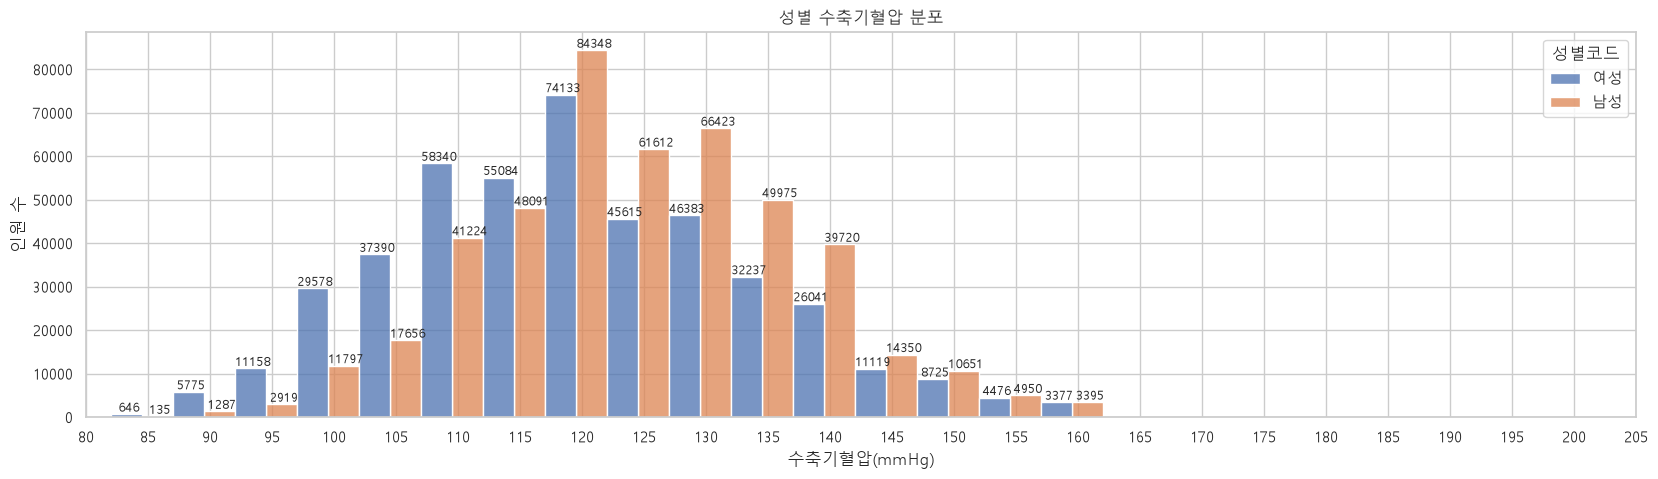

In [ ]:
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "수축기혈압", color = 'gray', binwidth=5, hue = "성별코드", multiple='dodge')
plt.title("성별 수축기혈압 분포")
plt.xlabel("수축기혈압(mmHg)")
plt.ylabel("인원 수")
plt.xticks(np.arange(80,271,5))
plt.xlim(80, 205)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 9)
plt.show()

그래프를 봤을 떄 남성 여성 모두 120mmHg에서 빈도가 높게 나타나고 전체적으로 봤을때 남성, 여성 모두 비슷한 그래프의 형상을 봐 중앙값이나 평균값이 비슷하다는 해석을 할 수 있다.

### 10\. 주요 수치형 변수 간 관계 분석

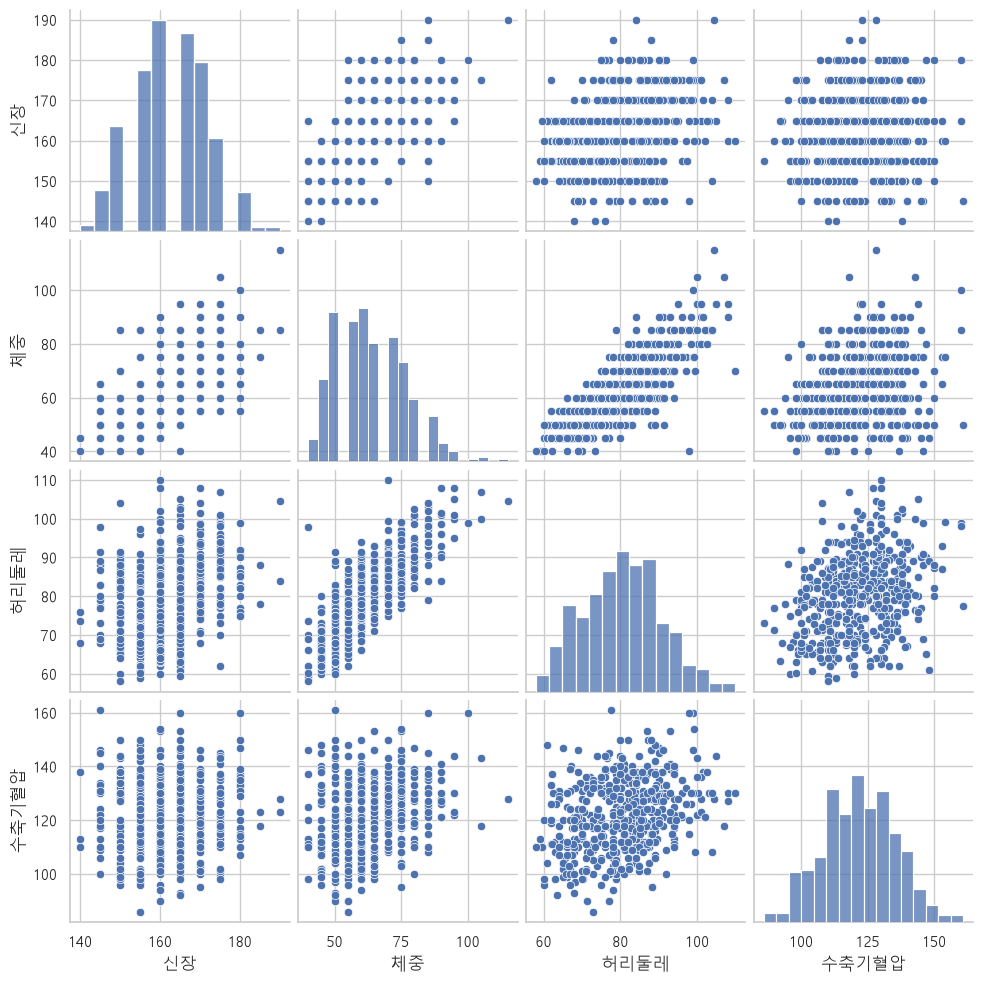

In [ ]:
pair_df = health_df[['신장', '체중', '허리둘레', '수축기혈압']].dropna().sample(500, random_state = 42) # 데이터가 많으므로 셈플링 

sns.pairplot(pair_df)
plt.show()


체중과 허리둘레에서 강한 양의 상관관계를 보여줌
또한 신장과 제충에서도 약한 양의 상관관계를 보여줌

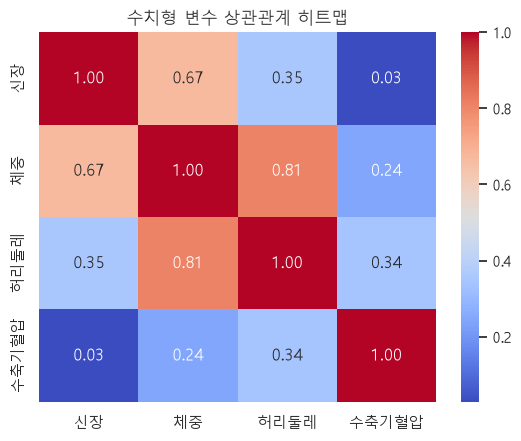

In [ ]:
corr = health_df[["신장", "체중", "허리둘레", "수축기혈압"]].corr()

sns.heatmap(corr, annot=True, cmap = 'coolwarm', fmt = ".2f")
plt.title("수치형 변수 상관관계 히트맵")
plt.show()

아까 위에서 봤듯이 (체중과 허리둘레), (체중과 신장) 사이의 양의 상관관계가 나타나고 있다.

이거를 통해 체중이 증가할 수록 허리둘레 역시 증가한다는 것을 알 수 있어 강한 양의 상관관계가 존재한다고 해석할 수 있다.

신장이 크면 체중이 많이 나간다는 것을 알 수 있어 약한 양의 상관관계가 존재한다고 해석할 수 있다.

(수축기혈압과 허리둘레) 사이에도 약간의 상관관계가 보여 허리 둘레의 증가가 혈압 상승과 일부 연관성이 있을 수 있음을 알 수 있다.

### 11\. 연령대별 주요 건강 지표 분석

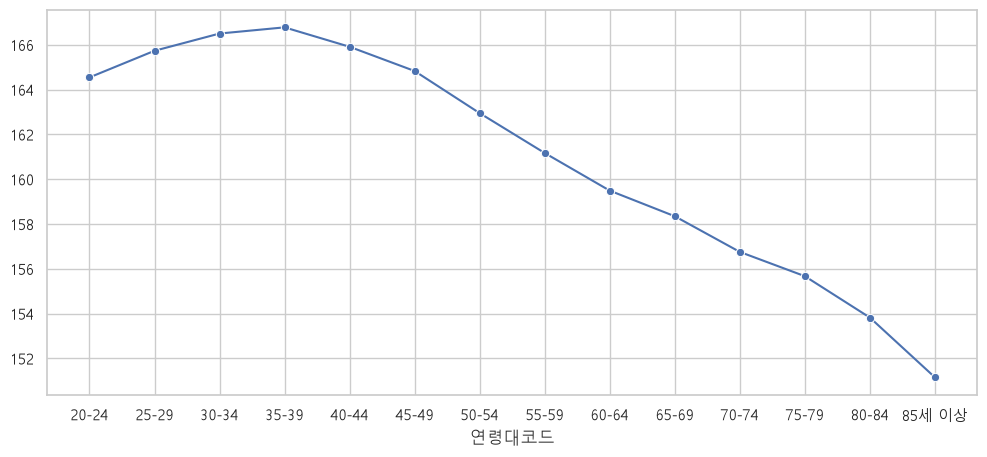

In [ ]:
age_height_mean = health_df.groupby("연령대코드")['신장'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x=age_height_mean.index, y=age_height_mean.values, marker='o')
plt.show()

30대 까지 평균신장이 증가하다가 40대 이후부터는 점점 감소하는 경향이 있다.

이는 나이가 들면서 체형 변화와 관련된 요인이 작용하기 때문일 수도 있다.

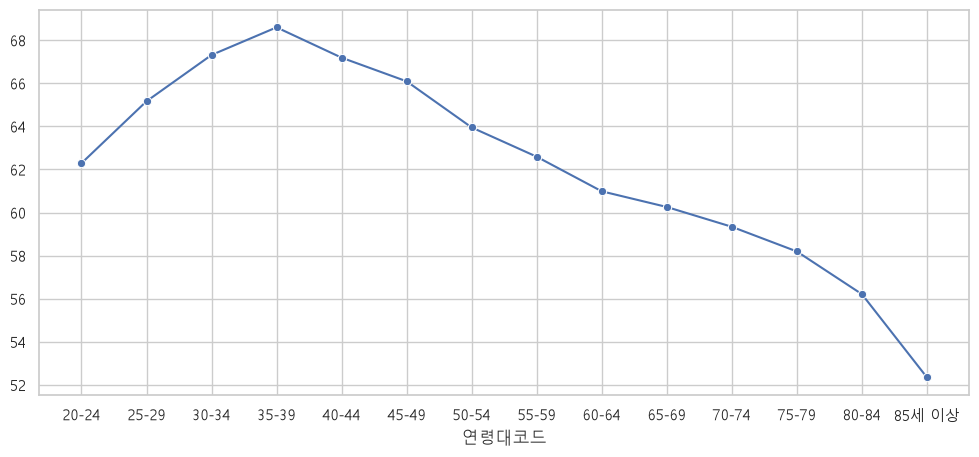

In [ ]:
age_weight_mean =health_df.groupby("연령대코드")['체중'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_weight_mean.index, y = age_weight_mean.values, marker= 'o')
plt.show()

아까 봤던 신장과 마찬가지로 30대까지 체중이 증가하다가 40대 이후부터는 점점 감소하는 경향을 보인다.

이는 나이가 들면서 활동량이 줄어 근육량 감소 등으로 인한 결과 일 수도 있다.

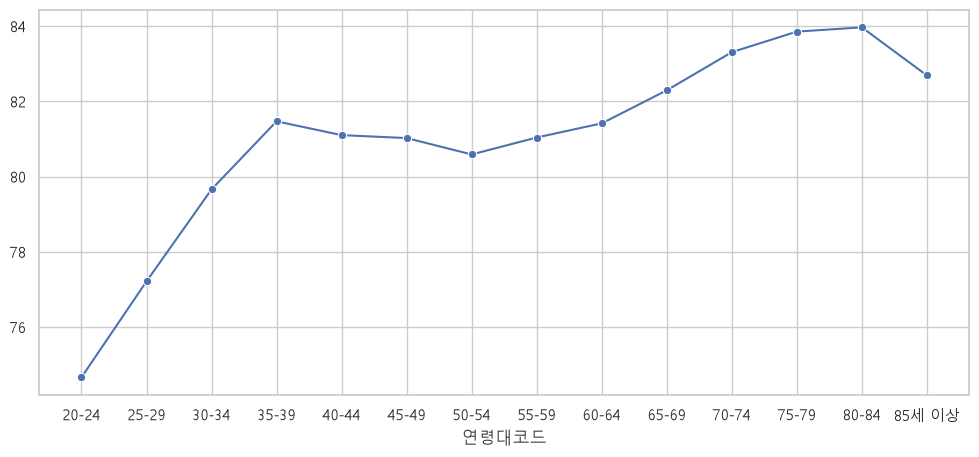

In [ ]:
age_waist_mean = health_df.groupby("연령대코드")['허리둘레'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_waist_mean.index, y = age_waist_mean.values, marker= 'o')
plt.show()

연령대별 허리 둘레는 20대부터 30대까지 급격하게 증가한후 50대까지는 일시적으로 정체되지만 60대 부터 다시 증가하여 80대 초반에 최고점을 찍고 85세 이후에는 감소되는 흐름을 보인다

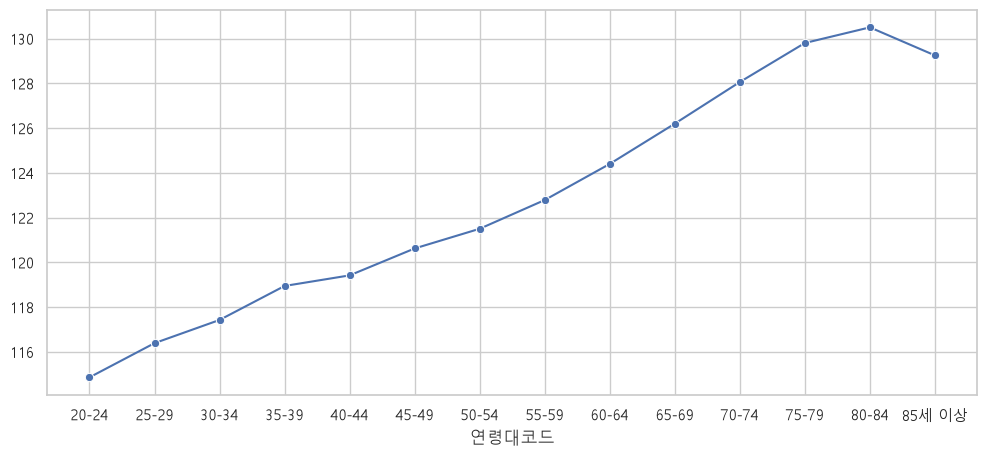

In [ ]:
age_blood_mean = health_df.groupby("연령대코드")['수축기혈압'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_blood_mean.index, y = age_blood_mean.values, marker= 'o')
plt.show()

수축기혈압은 연령대가 증가할수록 계속 높아지는 것을 확인할 수 있다. 
이는 나이가 들수록 혈관이 경직되고 심혈관계 질환의 위험이 증가하기 때문이다.

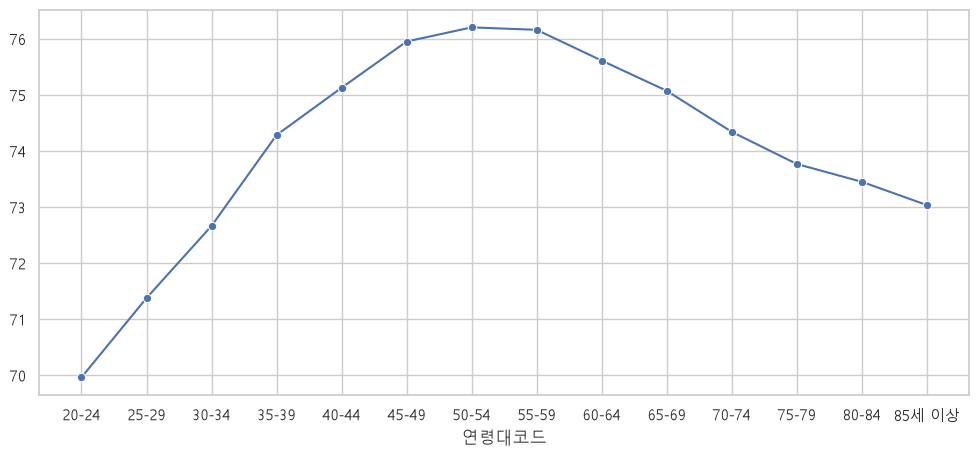

In [149]:
age_blood_mean = health_df.groupby("연령대코드")['이완기혈압'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_blood_mean.index, y = age_blood_mean.values, marker= 'o')
plt.show()

20~24세까지 이완기혈압이 점점 증가하다가 50~54세에 최대치를 찍고 그 이후부터는 점점 떨어지기 시작하는것을 알 수 있다.

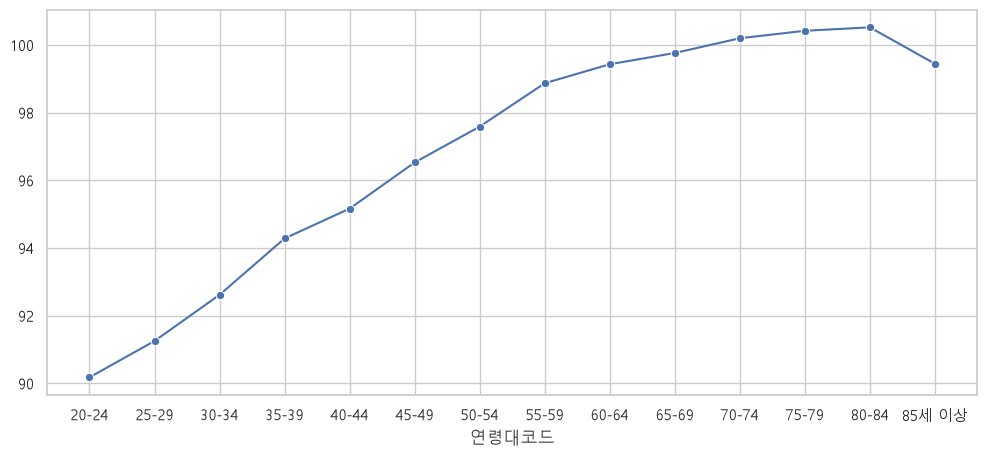

In [151]:
age_blood_mean = health_df.groupby("연령대코드")['식전혈당'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_blood_mean.index, y = age_blood_mean.values, marker= 'o')
plt.show()

식전혈당도 앞에 봤던 수축기 혈압과 마찬가지로 80~84세까지 연령대가 증가할수록 계속 높아지는 것을 볼 수 있고, 85세 이상부터는 낮아지는 것을 알 수 있다.

### 12\. 성별에 따른 흡연 및 음주 상태 비교


In [44]:
smoking_table = pd.crosstab(health_df["성별코드"], health_df["흡연상태"])
smoking_table

흡연상태,과거흡연,비흡연,현재흡연
성별코드,,,
남성,139790,178317,140426
여성,16112,416596,17369


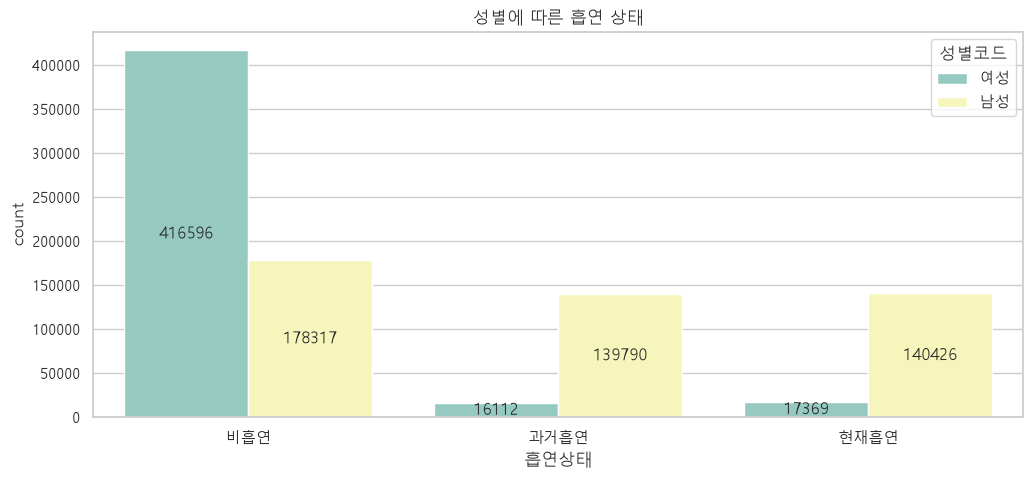

In [ ]:
plt.figure(figsize = (12,5))

ax = sns.countplot(data = health_df, x = "흡연상태", hue = '성별코드', palette = "Set3")
plt.title("성별에 따른 흡연 상태")
for c in ax.containers:
    ax.bar_label(c, fmt= '{:.0f}', label_type='center')

plt.show()

비흡연을 봤을 때는 여성이 남성보다 압도적으로 많이 있고

과거흡연, 현재흡연에서는 남성의 비율이 높게 나타난다.

전체적으로 봤을때 여성은 대부분 흡연을 하지 않는것으로 보이고 남성의 경우 모든 3가지 상태가 비슷하게 분포되어 있는 것으로 볼 수 있다.

In [45]:
drunking_table = pd.crosstab(health_df["성별코드"], health_df["음주여부"])
drunking_table

음주여부,비음주,음주
성별코드,,
남성,105810,352723
여성,202823,247254


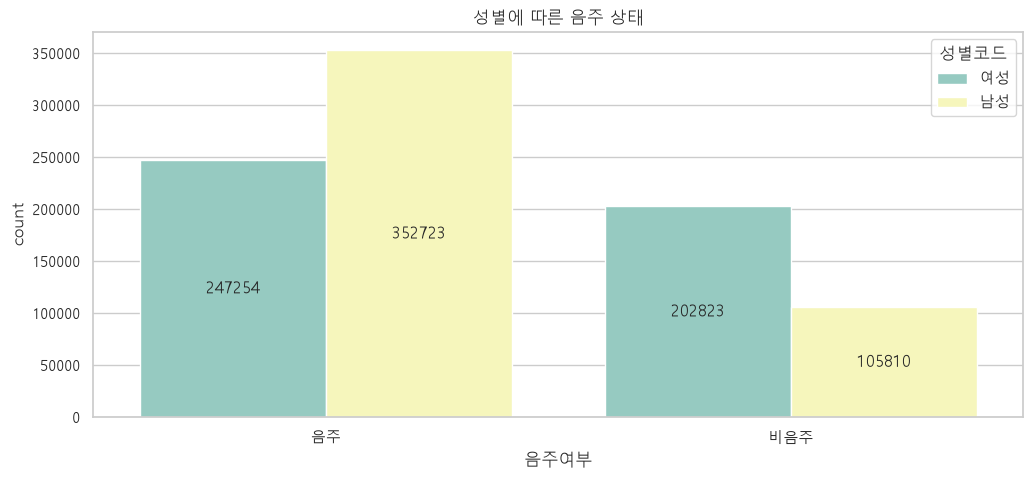

In [ ]:
# 성별에 따른 음주 상태를 비교해 보세요
plt.figure(figsize = (12,5))

ax = sns.countplot(data = health_df, x = "음주여부", hue = '성별코드', palette = "Set3")
plt.title("성별에 따른 음주 상태")
for c in ax.containers:
    ax.bar_label(c, fmt= '{:.0f}', label_type='center')

plt.show()

음주 상태의 비율은 남성이 여성보다 더 높게 나타나는 것을 볼 수 있다.

흡연 상태만큼 성별에 따라 극단적인 차이가 나지않지만 성별이 주된 영향을 끼치는 변수임을 알 수 있다.

### 13\. BMI 계산


$$BMI= \frac{체중(kg)}{신장(m)^2}$$

BMI에 따른 비만도 판단 기준:

- 저체중: BMI < 18.5
- 정상 체중: 18.5 ≤ BMI < 25
- 과체중: 25 ≤ BMI < 30
- 비만: BMI ≥ 30

In [ ]:
health_df["BMI"] = round(health_df['체중'] / (health_df['신장']/100)**2,2)

In [ ]:
health_df['비만도'] = health_df['BMI'].apply(lambda x:
                                        "저체중" if x < 18.5 else 
                                        "정상 체중" if 18.5 <= x < 25 else 
                                        "과체중" if 25 <= x < 30 else 
                                        "비만")

obesity_order = ['저체중', '정상 체중', '과체중', '비만'] # 순서가 있는 범주형 데이터로 변환

health_df["비만도"] = pd.Categorical(
    health_df["비만도"],
    categories = obesity_order,
    ordered=True)

health_df['비만도'].value_counts(normalize=True).sort_index()*100

비만도
저체중       5.388230
정상 체중    59.637688
과체중      29.019271
비만        5.954810
Name: proportion, dtype: float64

전체적인 비만도를 봤을때 정상체중에 가장 많은 비율을 차지하고 있고 그 다음으로 과체중, 비만, 저체중 순으로 나타나고 있다. 

### 14\. BMI 분포 시각화


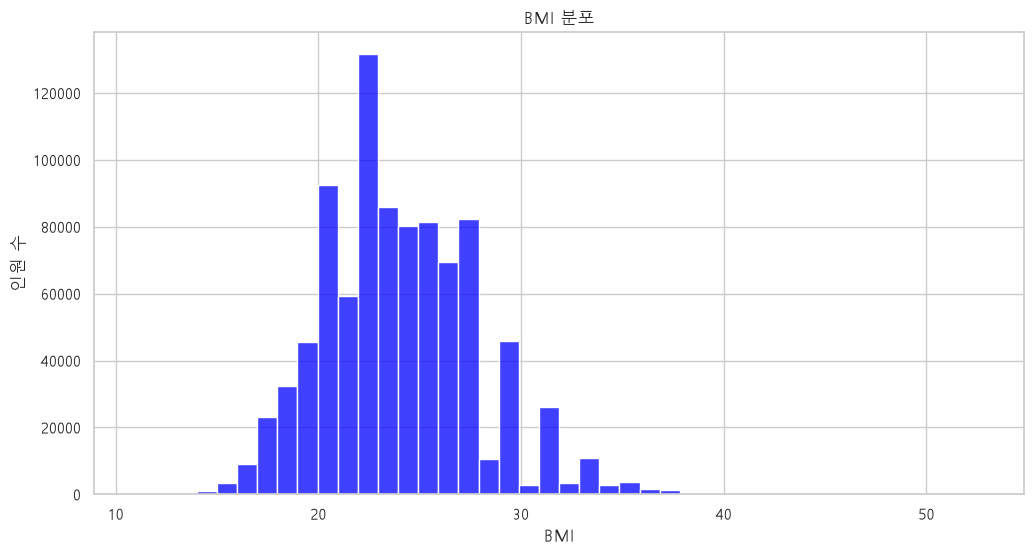

In [ ]:
plt.figure(figsize = (12,6))
sns.histplot(data = health_df, x = "BMI", color = 'blue', binwidth = 1)
plt.title("BMI 분포")
plt.xlabel("BMI")
plt.ylabel("인원 수")
plt.show()

BMI지수가 20~28 사이에 가장 많이 분포되어 있는거를 확인할 수 있다.

위의 그래프는 오른쪽에 극단적인 값이 존재하고 오른쪽으로 꼬리를 내린 형태로 분포되어 있음을 알 수 있다.

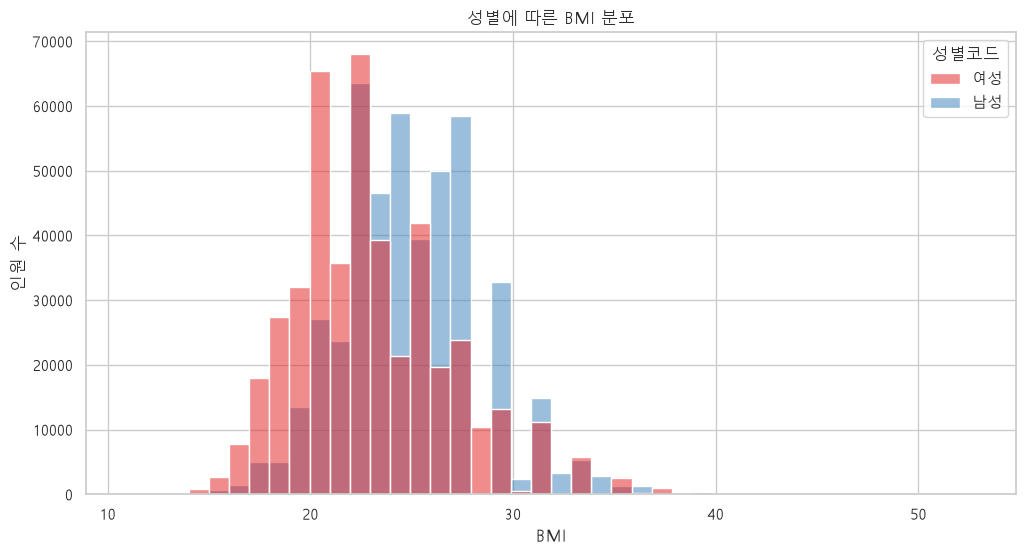

In [ ]:
plt.figure(figsize = (12,6))
sns.histplot(data=health_df, x="BMI", hue="성별코드", palette="Set1", 
            binwidth=1)
plt.title("성별에 따른 BMI 분포")
plt.xlabel("BMI")
plt.ylabel("인원 수")
plt.show()

남성의 BMI 지수가 전체적으로 오른쪽에 많이 배치 되어있어 남성의 BMI 중앙값이나 평균값이 여성보다 약간 더 높게 나타난다는 것을 추측할 수 있다.

하지만 남성과 여성의 집단이 전반적으로 비슷하게 보이고 크게 차이는 없어 보인다. 

또한 남성 여성 모두 오른쪽에 극단적인 값이 존재하고 오른쪽으로 꼬리를 내린 형태로 분포해 있다.

### 15\. 연령대별 BMI 및 비만도 비교

(15.0, 25.0)

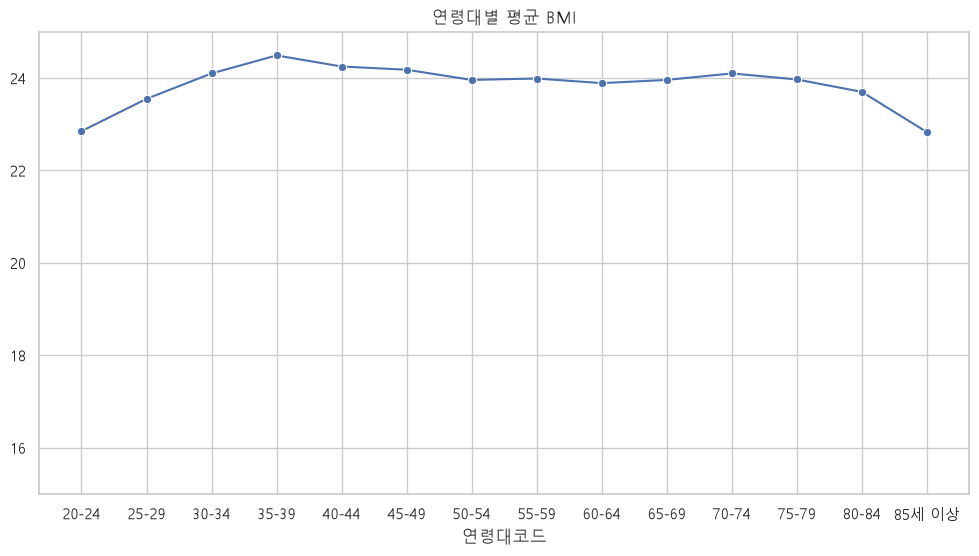

In [ ]:
age_BMI = round(health_df.groupby("연령대코드")["BMI"].mean(),2)

plt.figure(figsize = (12,6))
sns.lineplot(x = age_BMI.index, y = age_BMI.values, marker = 'o')
plt.title("연령대별 평균 BMI")
plt.ylim(15,25)


연령대별 BMI 평균은 모든 구간에서 20~25 사이에 분포 되어있어 차이가 크지 않다.

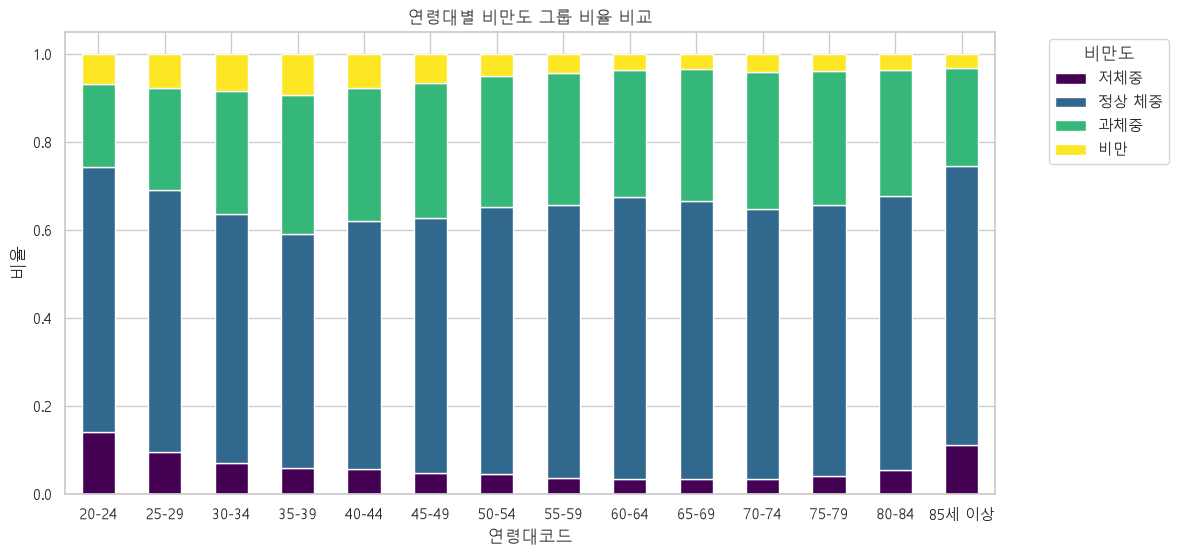

In [ ]:
age_fat_ratio = pd.crosstab(health_df['연령대코드'], health_df['비만도'], normalize='index')

order = ['저체중', '정상 체중', '과체중', '비만']
age_fat_ratio = age_fat_ratio[order]

age_fat_ratio.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

plt.title("연령대별 비만도 그룹 비율 비교")
plt.xlabel("연령대코드")
plt.ylabel("비율")
plt.legend(title="비만도", bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 옆으로 배치
plt.xticks(rotation=0)
plt.show()


비만도가 과체중인 비율이 20~24에서 35~39까지 증가한뒤 40~44부터는 점점 감소하다 80~84까지 증감이 비슷하게 유지되다 85세 이상부터는 비만과 과체중 비율이 낮아지는 것을 볼 수 있다.

비만도 구성비율을 보면 30대 후반까지 점점 비율이 높아지다가 고령층으로 갈 수록 다시 낮아지고 있다. 
즉 노화가 되면서 근육이나 지방이 빠져 비만율이 낮아진다고 추측할 수 있다.

그리고 모든 연령층에서 정상체중의 비율이 가장 높게 나타난다.

### 16\. BMI와 다른 건강 지표 간의 관계 분석



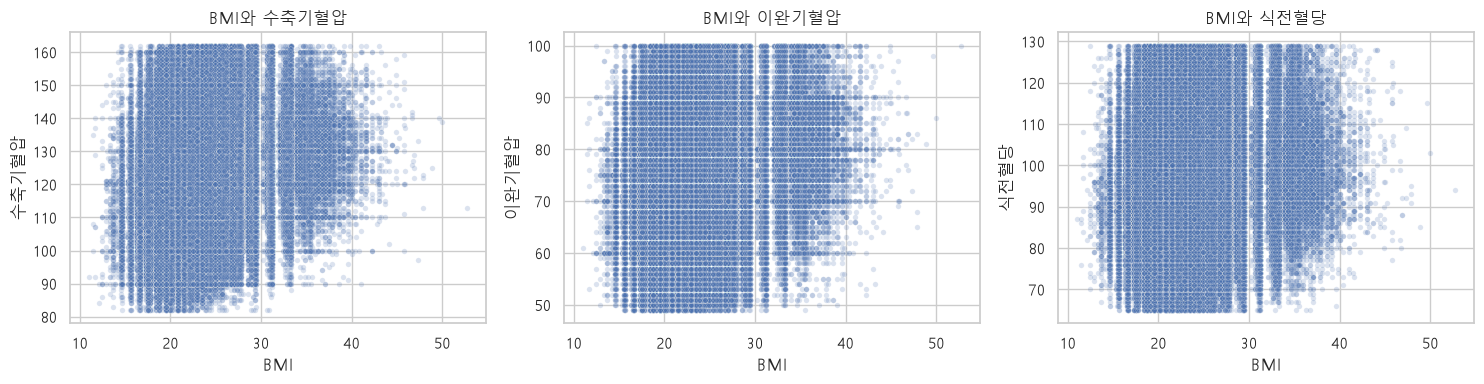

In [ ]:
fig, axes = plt.subplots(1,3, figsize = (15,4))

sns.scatterplot(data = health_df, x = "BMI", y = "수축기혈압", alpha=0.2, s=15, ax = axes[0])
axes[0].set_title("BMI와 수축기혈압")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("수축기혈압")

sns.scatterplot(data = health_df, x = "BMI", y = "이완기혈압", alpha=0.2, s=15, ax = axes[1])
axes[1].set_title("BMI와 이완기혈압")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("이완기혈압")

sns.scatterplot(data = health_df, x = "BMI", y = "식전혈당", alpha=0.2, s=15, ax = axes[2])
axes[2].set_title("BMI와 식전혈당")
axes[2].set_xlabel("BMI")
axes[2].set_ylabel("식전혈당")

fig.tight_layout()
plt.show()

BMI가 증가할수록 모두 뚜렷한 상관관계가 보이지 않음

지표를 보면 모두 넓게 분포되어 있으나 BMI와 약한 양의 상관관계가 존재한다고 해석할 수 있다.

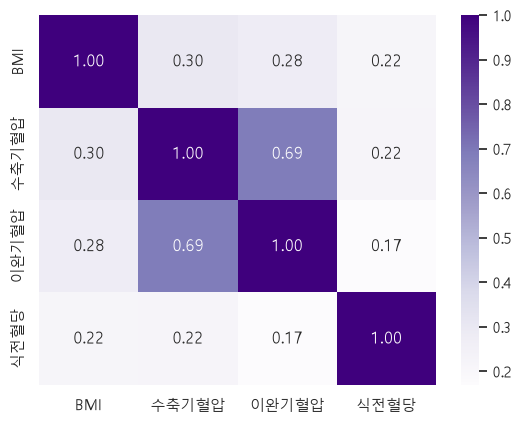

In [ ]:
corr = health_df[["BMI", "수축기혈압", "이완기혈압", "식전혈당"]].corr()

sns.heatmap(corr, annot=True, cmap = 'Purples', fmt = ".2f")
plt.show()

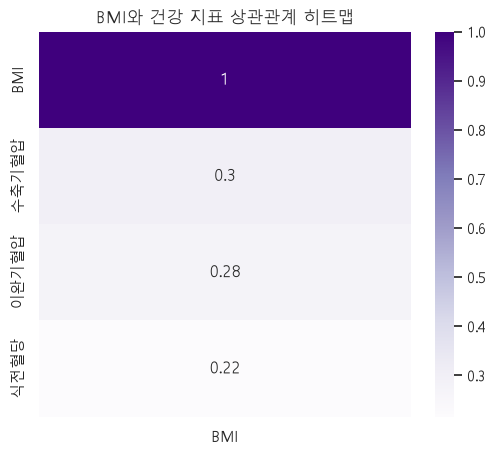

In [94]:
plt.figure(figsize = (6,5))

sns.heatmap(corr[["BMI"]], annot=True, cmap = 'Purples')
plt.title("BMI와 건강 지표 상관관계 히트맵")
plt.show()

수축기혈압, 이완기혈압, 식전혈당은 BMI와 0.22 ~ 0.3의 상관관계를 갖고 있으며 모두 약한 양의 상관관계가 있음을 알 수 있다.

### 17\. 비만도 그룹별 흡연 및 음주 상태 비교


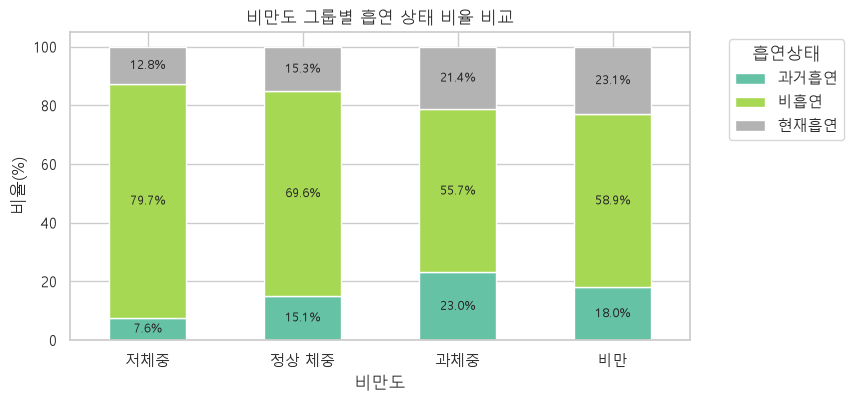

In [ ]:
age_fat_ratio = pd.crosstab(health_df['비만도'], health_df['흡연상태'], normalize='index')*100

ax = age_fat_ratio.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='Set2')

for container in ax.containers:
    label = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = label, label_type="center", fontsize =9)

plt.title("비만도 그룹별 흡연 상태 비율 비교")
plt.xlabel("비만도")
plt.ylabel("비율(%)")
plt.legend(title="흡연상태", bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 옆으로 배치
plt.xticks(rotation=0)
plt.show()


비만도가 높아질수록 비흡연 상태는 낮아지고 과거흡연과 현재 흡연의 비율은 높아지고 있다

즉 흡연 상태가 비만도 사이에 상관관계가 존재할 수 있음을 시사한다.

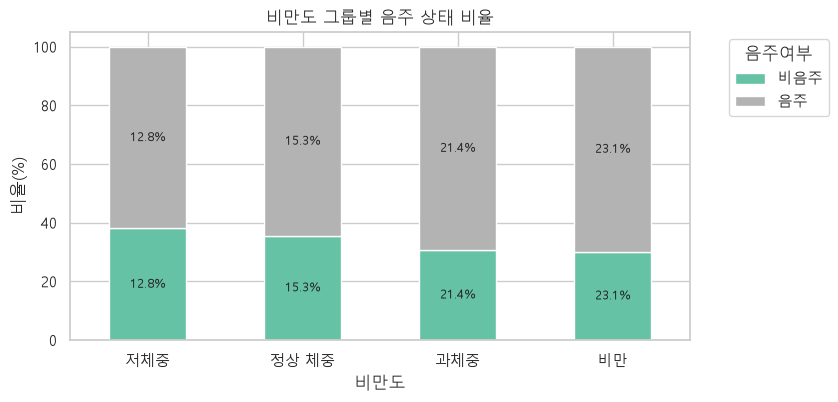

In [ ]:
obesity_drunking = pd.crosstab(health_df["비만도"], health_df["음주여부"], normalize='index')*100

ax = obesity_drunking.plot(kind = 'bar', stacked=True, figsize=(8,4), colormap='Set2')

for container in ax.containers:
    labels = [f'{v:.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = label, label_type="center", fontsize = 9)

plt.title("비만도 그룹별 음주 상태 비율")
plt.ylabel("비율(%)")
plt.xticks(rotation = 0)
plt.legend(title="음주여부", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

비만도가 높아질수록 음주 비율이 높아지는 것을 알 수 있다.

즉 음주여부와 비만도 사이에 상관관계가 존재할 수 있음을 시사한다.

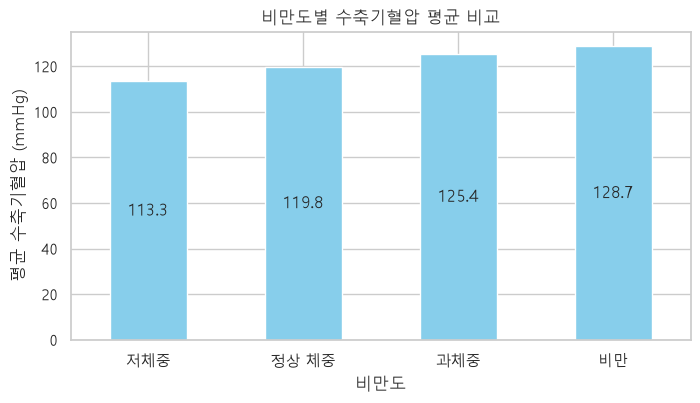

In [ ]:
obesity_bp = health_df.groupby("비만도")["수축기혈압"].mean()

ax = obesity_bp.plot(kind = 'bar', figsize =(8,4), color = "skyblue")

for container in ax.containers:
    labels = [f'{v:.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = labels, label_type = 'center')

plt.xticks(rotation = 1)
plt.title("비만도별 수축기혈압 평균 비교")
plt.ylabel("평균 수축기혈압 (mmHg)")
plt.show()



비만도가 증가할수록 수축기혈압도 같이 증가하는 것을 알 수 있다.

즉 비만도와 수축기혈압 사이에는 상관관계가 존재할 수 있다는 것을 시사한다.

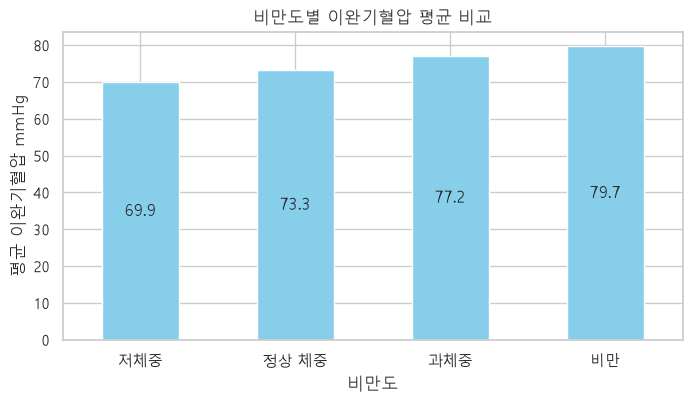

In [171]:
obesity_bp = health_df.groupby("비만도")["이완기혈압"].mean()

ax = obesity_bp.plot(kind = 'bar', figsize =(8,4), color = "skyblue")

for container in ax.containers:
    labels = [f'{v:.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = labels, label_type = 'center')

plt.xticks(rotation = 1)
plt.title("비만도별 이완기혈압 평균 비교")
plt.ylabel("평균 이완기혈압 (mmHg)")
plt.show()

비만도가 증가할수록 이완기혈압의 평균도 증가한다는 것을 알 수 있다.

즉 비만도와 이완기혈압 간의 상관관계가 존재한다는 것을 시사한다.

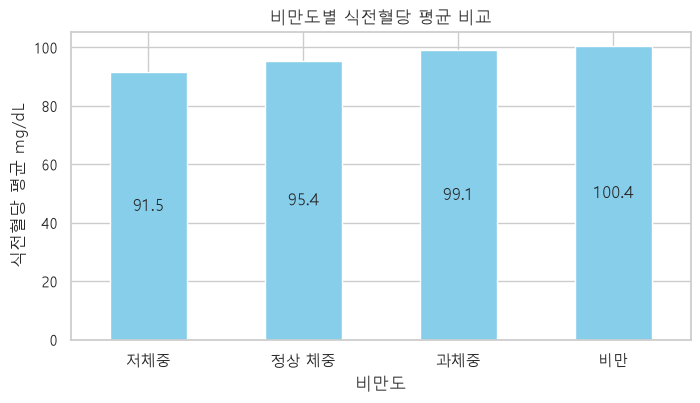

In [173]:
obesity_bp = health_df.groupby("비만도")["식전혈당"].mean()

ax = obesity_bp.plot(kind = 'bar', figsize =(8,4), color = "skyblue")

for container in ax.containers:
    labels = [f'{v:.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = labels, label_type = 'center')

plt.xticks(rotation = 1)
plt.title("비만도별 식전혈당 평균 비교")
plt.ylabel("식전혈당 평균 (mg/dL)")
plt.show()

비만도가 증가할수록 식전혈당의 평균도 증가한다는 것을 알 수 있다.

즉 비만도와 식전혈당 간의 상관관계가 존재한다는 것을 시사한다.

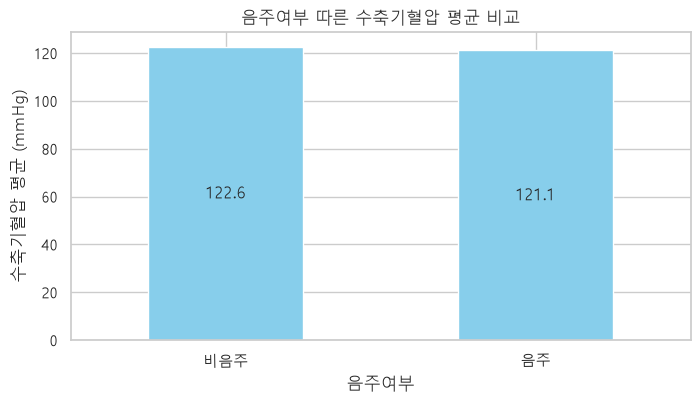

In [191]:
alcohol_bp = health_df.groupby("음주여부")["수축기혈압"].mean()

ax = alcohol_bp.plot(kind = 'bar', figsize =(8,4), color = "skyblue")

for container in ax.containers:
    labels = [f'{v:.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = labels, label_type = 'center')

plt.xticks(rotation = 1)
plt.title("음주여부 따른 수축기혈압 평균 비교")
plt.ylabel("수축기혈압 평균 (mmHg)")
plt.show()

음주여부에 따른 수축기혈압 평균은 비음주는 약 122.6mmHg, 음주는 약 121.1mmHg로 두 집단간의 유의미한 차이가 발견되지 않음

즉 음주여부보다는 비만도나 다른 복합적인 요인이 혈압에 큰 영향을 준다는 사실을 알 수 있음

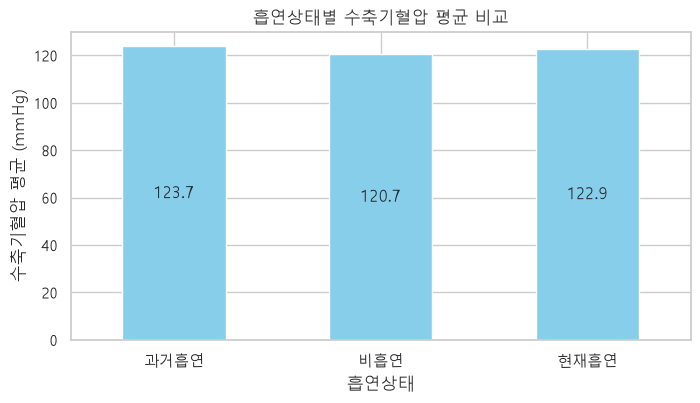

In [186]:
smoking_bp = health_df.groupby("흡연상태")["수축기혈압"].mean()

ax = smoking_bp.plot(kind = 'bar', figsize =(8,4), color = "skyblue")

for container in ax.containers:
    labels = [f'{v:.1f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels = labels, label_type = 'center')

plt.xticks(rotation = 1)
plt.title("흡연상태에 따른 수축기혈압 평균 비교")
plt.ylabel("수축기혈압 평균 (mmHg)")
plt.show()

흡연상태에 따른 수축기혈압 평균은 과거흡연 약 123.7mmHg, 비흡연 약 120.7mmHg, 현재흡연 122.9mmHg로 집단간의 유의미한 차이가 발견되지 않음

즉 흡연상태보다는 비만도나 다른 복합적인 요인이 혈압에 큰 영향을 준다는 사실을 알 수 있음